# Import Libraries

In [14]:
import pandas as pd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('/content/drive/MyDrive/Agri_RS_AI_Project')

# Import dataset

In [15]:
df = pd.read_csv('/content/drive/MyDrive/Agri_RS_AI_Project/03_Phase_1_5_Validation_Layer_&_Time_Series_Entry/python_validation/6_Cloud_and_Noise_Validation/data/ndvi_gee_export.csv')

## Convert Date Column, Sort Time and Set Time Index

In [16]:
from src.time_processing import prepare_time_index

df = prepare_time_index(df, date_col = "Date", dayfirst=True) #default "date" and "dayfirst=False"


# Basic Cleaning

Hare make a raw and clean file, later clean the value which is more than one and less than one. and later the pysical filtering.

In [17]:
from src.cleaning import clean_ndvi

df = clean_ndvi(df)  # default ndvi_col="NDVI", jump_threshold=0.3

# Cloud Contamination Logic

In [18]:
df['t-1'] = df['NDVI'].shift(1)
df['t']   = df['NDVI']
df['t+1'] = df['NDVI'].shift(-1)

cloud_mask = (
    (df['t'] < df['t-1'] - 0.4) &
    (df['t+1'] > df['t'] + 0.3)
)

## Cloud Flag and Replace cloud pixels with NaN

In [19]:
df['cloud_flag'] = 0
df.loc[cloud_mask, 'cloud_flag'] = 1

df.loc[df['cloud_flag'] == 1, 'NDVI_clean'] = np.nan

# Imputation

In [20]:
df['NDVI_clean'] = df['NDVI_clean'].interpolate()

# Noise Spike Detection/ Outlier detection



In [21]:
from src.noise_spike import detect_spike_outliers

df, spikes = detect_spike_outliers(df)
print(spikes)

             NDVI  NDVI_raw  NDVI_clean  change    t-1      t    t+1  \
Date                                                                   
2024-02-01  0.050     0.050    0.591333  -0.504  0.554  0.050  0.675   
2024-02-15  0.675     0.675    0.628667   0.625  0.050  0.675  0.666   
2024-03-27 -0.150    -0.150    0.529667  -0.726  0.576 -0.150  0.515   
2024-04-01  0.515     0.515    0.483333   0.665 -0.150  0.515  0.437   
2024-07-13  0.980     0.980   -0.184000   1.128 -0.148  0.980 -0.268   
2024-07-20 -0.268    -0.268   -0.220000  -1.248  0.980 -0.268 -0.256   

            cloud_flag  spike_flag  
Date                                
2024-02-01           1        True  
2024-02-15           0        True  
2024-03-27           1        True  
2024-04-01           0        True  
2024-07-13           0        True  
2024-07-20           0        True  


In [22]:
from src.noise_spike import detect_zscore_outliers

df, z_outlier = detect_zscore_outliers(df)
print(z_outlier)

Empty DataFrame
Columns: [NDVI, NDVI_raw, NDVI_clean, change, t-1, t, t+1, cloud_flag, spike_flag, z_score, z_flag]
Index: []


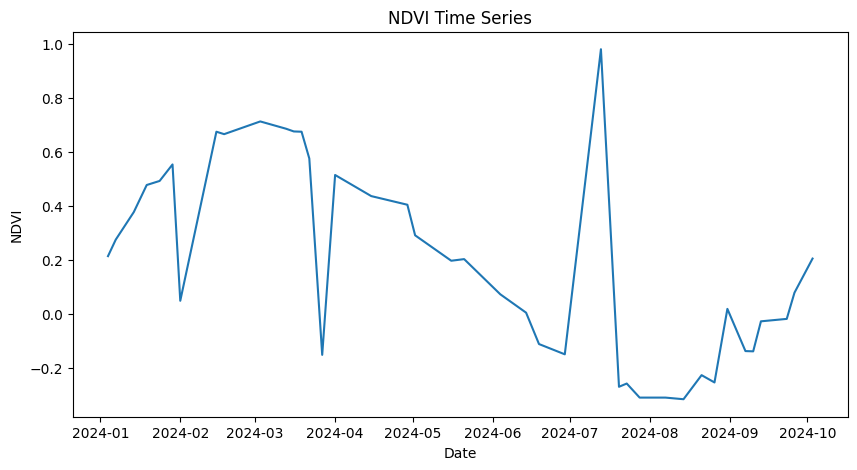

In [23]:
plt.figure(figsize=(10,5))

plt.plot(df.index, df['NDVI'])

plt.xlabel("Date")
plt.ylabel("NDVI")
plt.title("NDVI Time Series")

plt.show()

# Rolling Mean (Noise Filter)

In [28]:
from src.smoothing import smooth_ndvi
df = smooth_ndvi(df)

# Compare Raw vs Clean vs Smooth

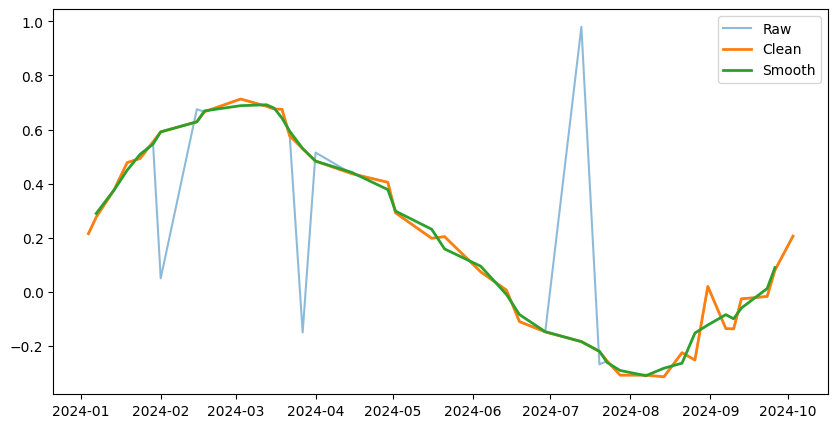

In [29]:
plt.figure(figsize=(10,5))

plt.plot(df['NDVI_raw'], label='Raw', alpha=0.5)
plt.plot(df['NDVI_clean'], label='Clean', linewidth=2)
plt.plot(df['NDVI_smooth'], label='Smooth', linewidth=2)

plt.legend()
plt.show()